# Iris Classification & Machine Learning Pipeline


The workflow includes:
- data exploration  
- preprocessing  
- model training  
- hyperparameter tuning  
- evaluation  


## Key Results

- Best Model: Logistic Regression
- Cross-validation Accuracy: ~0.96
- Test Accuracy: 1.00
- Dataset is balanced
- Classes are well separable (especially setosa)

## Objective

The objective of this project is to build and compare multiple machine learning models for classifying iris flower species.

## Introduction to the Iris Dataset

The **Iris Dataset** is a widely used benchmark dataset in machine learning, commonly applied for classification tasks.

It contains measurements from **three different species of iris flowers**:

| Numeric Label | Species Name |
|---------------|--------------|
| 0             | Setosa       |
| 1             | Versicolor   |
| 2             | Virginica    |

For each flower, four measurements are recorded:

| Feature | Description |
|---------|-------------|
| `sepal length` | length of the sepal (cm) |
| `sepal width`  | width of the sepal (cm)  |
| `petal length` | length of the petal (cm) |
| `petal width`  | width of the petal (cm)  |



## Dataset Exploration

The Iris dataset was loaded and converted into a pandas DataFrame for analysis.

Basic properties of the dataset such as shape, feature names, and target classes were examined to understand its structure.

In [2]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

# we create the DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# we show first 5 rows, shape, column names and target names
print("First 5 rows:\n", df.head(), "\n")
print("Shape:", df.shape, "\n")
print("Column (feature) names:", df.columns.tolist(), "\n")
print("Target names:", iris.target_names.tolist(), "\n")


First 5 rows:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2 

Shape: (150, 4) 

Column (feature) names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'] 

Target names: ['setosa', 'versicolor', 'virginica'] 



## Data Analysis & Visualization

Descriptive statistics were analyzed to understand the distribution of numerical features.

The class distribution was visualized using a countplot to examine whether the dataset is balanced across different species.

Summary statistics for numerical features:
        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     species  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


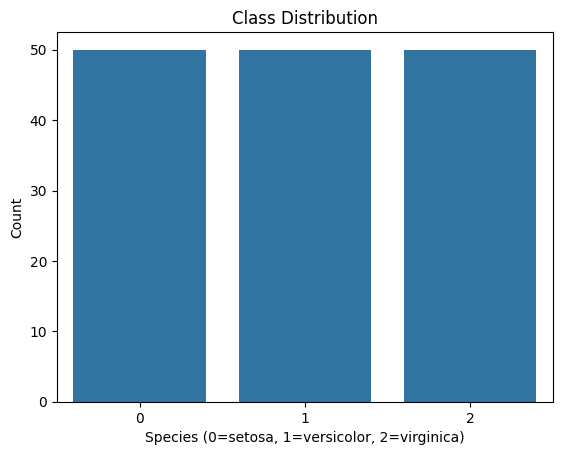

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

df['species'] = iris.target

# we display summary statistics
print("Summary statistics for numerical features:\n",df.describe())

# we visualize the class distribution with a countplot
plt.figure()
sns.countplot(x="species", data=df)
plt.title("Class Distribution")
plt.xlabel("Species (0=setosa, 1=versicolor, 2=virginica)")
plt.ylabel("Count")
plt.show()


    
    The dataset is balanced, with each class containing an equal number of samples.

## Data Preprocessing

The dataset was split into training and test sets to evaluate model performance on unseen data.

Feature scaling was applied using StandardScaler to normalize the input features and improve model performance.


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# we name features (X) ve target (y)
X = df[iris.feature_names]
y = df["species"]

# we split the dataset into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# we scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Feature scaling was applied only on the training data to prevent data leakage. The same transformation was then applied to the test set using the fitted scaler.

Scaling is important because many machine learning algorithms are sensitive to feature magnitudes.

## Model Training & Comparison

Multiple machine learning models, including Logistic Regression, K-Nearest Neighbors, Support Vector Machine, and Random Forest, were trained on the dataset.

Cross-validation was used to evaluate model performance and compare their accuracy scores.

                 model  mean_accuracy
0  Logistic Regression       0.958333
1                  KNN       0.925000
2                  SVM       0.950000
3        Random Forest       0.950000


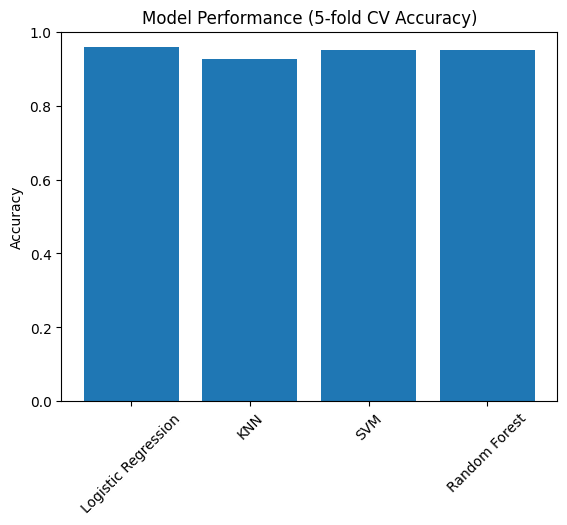

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# we choose all models from list
models = {"Logistic Regression": LogisticRegression(max_iter=200), "KNN": KNeighborsClassifier(), "SVM": SVC(), "Random Forest": RandomForestClassifier(random_state=42)}

results = []

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    results.append({"model": name, "mean_accuracy": scores.mean()})

results_df = pd.DataFrame(results)
print(results_df)


# we plot the performance of all 4 models
plt.figure()
plt.bar(results_df["model"], results_df["mean_accuracy"])
plt.ylim(0, 1)
plt.title("Model Performance (5-fold CV Accuracy)")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

Logistic Regression achieved the highest cross-validation accuracy among the models, indicating strong generalization performance.

## Hyperparameter Tuning

GridSearchCV was used to find the optimal hyperparameters for selected models.

The results were compared with default model performances to determine whether tuning improved accuracy.

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# this is the base of our Logistic Regression model
log_reg = LogisticRegression(max_iter=200)

# this is the hyperparameter grid for Logistic Regression
param_grid = {"C": [0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5
)

grid.fit(X_train_scaled, y_train)

# we print the best parameters and cross-validation accuracy
print("Best parameters:", grid.best_params_)
print("Best cross-validation accuracy:", grid.best_score_)

Best parameters: {'C': 1}
Best cross-validation accuracy: 0.9583333333333334


Hyperparameter tuning did not significantly improve performance, likely because the dataset is small and relatively simple.

## Model Evaluation

The best-performing model was evaluated using the test dataset.

Performance metrics such as accuracy, confusion matrix, and classification report were used to assess model effectiveness.

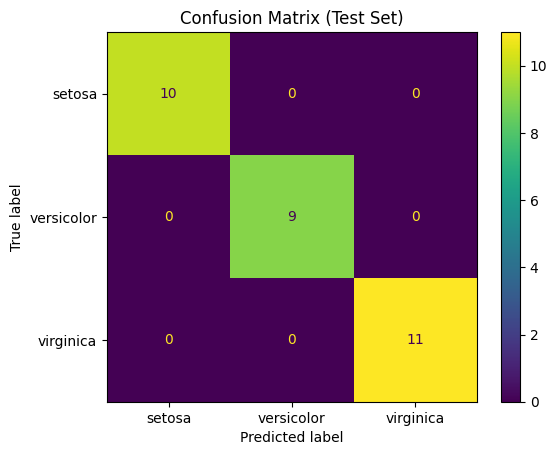

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# for getting the best tuned model
best_model = grid.best_estimator_

# for predicting the test set
y_pred_test = best_model.predict(X_test_scaled)

# this is the Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.title("Confusion Matrix (Test Set)")
plt.show()

# this is the Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_test, target_names=iris.target_names))


The confusion matrix shows that all test samples were correctly classified, indicating perfect model performance on this dataset.

## PCA Visualization

Principal Component Analysis (PCA) was applied to reduce the dataset to two dimensions.

This allowed visualization of class separability and helped interpret how well different classes are distinguished in feature space.

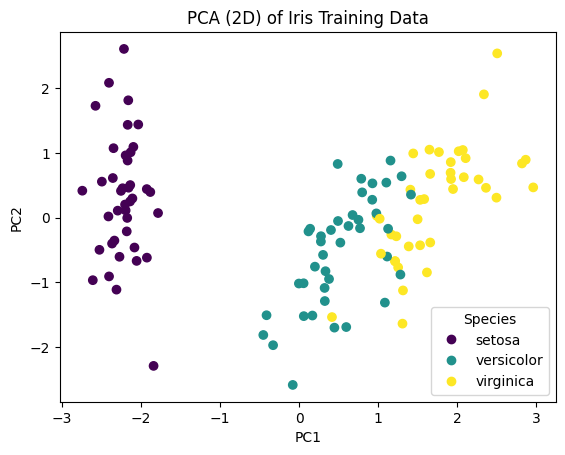

In [8]:
from sklearn.decomposition import PCA

# this is the PCA with 2 components
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# we scatter plot of PCA results
plt.figure()
scatter = plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2D) of Iris Training Data")

# we add legend
handles, _ = scatter.legend_elements()
plt.legend(handles, iris.target_names, title="Species")

plt.show()


The PCA visualization shows that the 'setosa' class is clearly separated, while 'versicolor' and 'virginica' have some overlap.